In [1]:
import sys 
import os 
from pathlib import Path 
sys.path.insert(0, str(Path.cwd().parent)) 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import matplotlib.patches as mpatches 
import seaborn as sns 
from datetime import datetime, date 

from app.services.fred import FREDClient 

In [2]:
fred = FREDClient() 

In [3]:
indicators = {
    "PCEPI": "PCE Price Index", 
    "UNRATE": "Unemployment Rate",
    "INDPRO": "Industrial Production", 
    "DGS10": "10-Year Treasury Yield",
    "DGS2": "2-Year Treasury Yield",
    "FEDFUNDS": "Federal Funds Rate"
}


start_date = date(2000, 1, 1) 
raw_data = {} 

for indicator_id, name in indicators.items(): 
    try: 
        observations = await fred.fetch_series(
            series_id=indicator_id,
            start_date=start_date
        )
        raw_data[indicator_id] = observations 
    except Exception as e: 
        print(f"Error fetching from FRED: {e}")
        

In [4]:
dfs = {}
for indicator_id, observations in raw_data.items(): 
    df = pd.DataFrame(observations)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce') 
    df = df.set_index('date')
    df = df[['value']].rename(columns={'value': indicator_id}) 

    # resample to monthly 
    df_monthly = df.resample('ME').last() 
    dfs[indicator_id] = df_monthly 


In [5]:
# merge into 1 df, outer join to preserve dates 
macro_df = pd.concat(dfs.values(), axis=1, join='outer') 
macro_df = macro_df.sort_index() 

print(f"Missing values: ")
print(macro_df.isnull().sum())

Missing values: 
PCEPI       2
UNRATE      2
INDPRO      1
DGS10       0
DGS2        0
FEDFUNDS    1
dtype: int64


In [6]:
# calc 10y-2y bond spread 
macro_df['SPREAD_10Y2Y'] = macro_df['DGS10'] - macro_df['DGS2'] 
print("Bond Spread Stats")
print(macro_df['SPREAD_10Y2Y'].describe()) 
print(f"Latest Spread: {macro_df['SPREAD_10Y2Y'].iloc[-1]:.2f}%")

Bond Spread Stats
count    315.000000
mean       1.053143
std        0.967225
min       -1.060000
25%        0.215000
50%        1.050000
75%        1.890000
max        2.840000
Name: SPREAD_10Y2Y, dtype: float64
Latest Spread: 0.49%


In [7]:
fed_funds = macro_df['FEDFUNDS'].resample('ME').last().dropna()

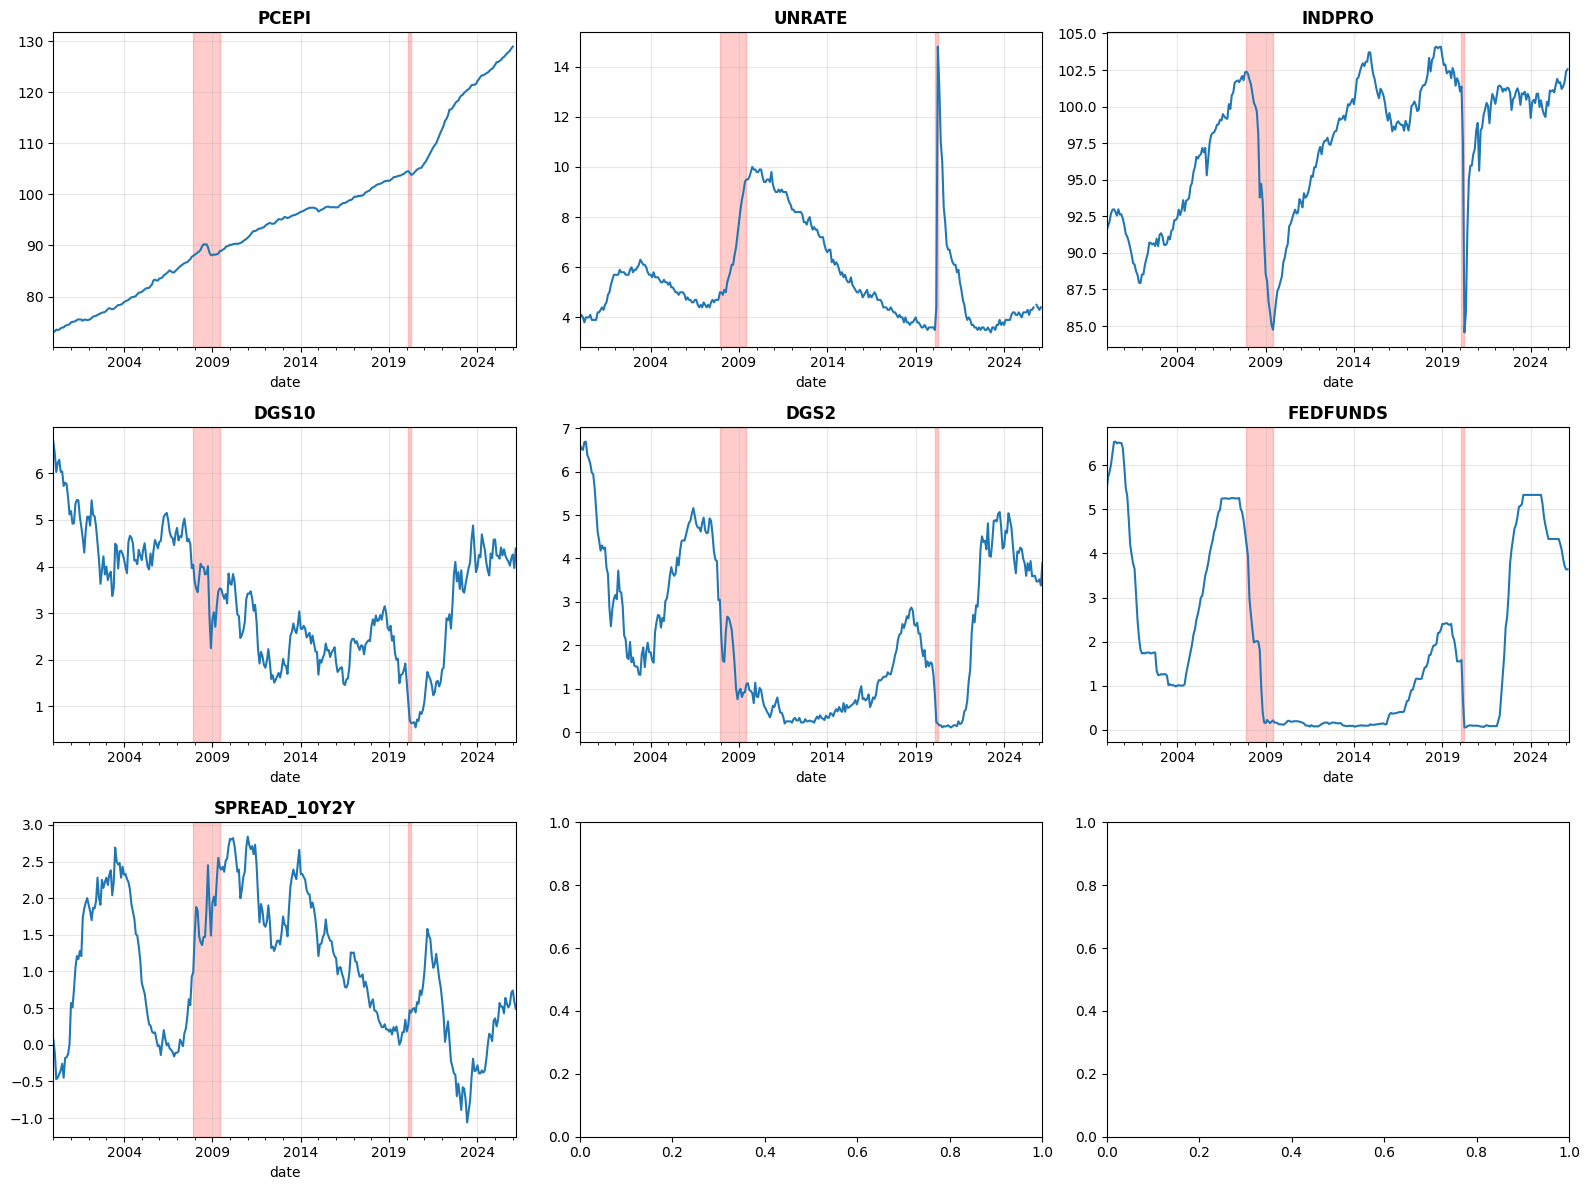

In [8]:
# plot the series 
fix, axes = plt.subplots(3, 3, figsize=(16, 12)) 
axes = axes.flatten()  

for i, col in enumerate(macro_df.columns): 
    ax = axes[i]
    macro_df[col].plot(ax=ax, linewidth=1.5) 
    ax.set_title(f'{col}', fontsize=12, fontweight='bold') 
    ax.set_label('')
    ax.grid(True, alpha=0.3) 

    # some recenssion periods 
    ax.axvspan('2007-12', '2009-06', alpha=0.2, color='red', label='GFC')
    ax.axvspan('2020-02', '2020-04', alpha=0.2, color='red', label='COVID')
plt.tight_layout() 
plt.show()


In [9]:
macro_df = macro_df.drop(columns=['FEDFUNDS'])

In [10]:
INDICATORS = macro_df.columns  
EWM_SPAN = 36 # 3-year lookkback for mean/std 
ewm_mean = macro_df[INDICATORS].ewm(span=EWM_SPAN).mean() 
ewm_std = macro_df[INDICATORS].ewm(span=EWM_SPAN).std() 
z_scores = (macro_df[INDICATORS] - ewm_mean) / ewm_std 
z_scores = z_scores.dropna() 


In [11]:
from hmmlearn.hmm import GaussianHMM 
X = z_scores.values 
model = GaussianHMM(
    n_components=2, 
    covariance_type='full', 
    n_iter=200, 
    random_state=42, 
    tol=0.01
)
model.fit(X)

GaussianHMM(covariance_type='full', n_components=2, n_iter=200, random_state=42)

In [12]:
hidden_states = model.predict(X)
state_probs = model.predict_proba(X) 
z_scores['regime'] = hidden_states
z_scores['confidence'] = state_probs.max(axis=1)

In [13]:
z_scores

,PCEPI,UNRATE,INDPRO,DGS10,DGS2,SPREAD_10Y2Y,regime,confidence
date,,,,,,,,
2000-02-29,0.687465,0.687465,0.687465,-0.687465,-0.687465,-0.687465,1,1.000000
2000-03-31,1.007783,-0.576608,0.983375,-1.019311,-0.791465,-1.048644,1,1.000000
2000-04-30,0.635424,-1.322711,1.235012,-0.359158,1.187939,-0.750225,1,1.000000
2000-05-31,0.724174,0.210582,1.147375,-0.126628,0.969547,-0.487233,1,0.999999
2000-06-30,1.237175,0.192315,0.955656,-0.972771,-1.474328,-0.249002,1,1.000000
...,...,...,...,...,...,...,...,...
2025-08-31,0.872500,0.179866,0.770818,0.370907,-0.184038,1.058898,0,1.000000
2025-09-30,0.882125,0.285939,0.767150,0.283554,-0.170381,0.858479,0,1.000000
2025-11-30,0.880023,0.390168,0.508543,0.109750,-0.276598,0.771357,0,1.000000


In [14]:
#  take the 1s and mean, take the 0s and mean 
state_means = z_scores.groupby('regime')[INDICATORS].mean() 
state_means

,PCEPI,UNRATE,INDPRO,DGS10,DGS2,SPREAD_10Y2Y
regime,,,,,,
0,1.027882,0.578676,-0.076713,-0.535428,-0.762349,0.826320
1,1.039160,-0.645130,0.602266,0.053537,0.607252,-0.862668


In [15]:
expansion_state = state_means['INDPRO'].idxmax() 
contraction_state = 1 - expansion_state 
REGIME_LABELS = {
    expansion_state: 'expansion',
    contraction_state: 'contraction'
}

z_scores['regime_label'] = z_scores['regime'].map(REGIME_LABELS)

In [16]:
# Composite score
z_aligned = z_scores[INDICATORS].copy()
z_aligned['UNRATE'] = -z_aligned['UNRATE']
composite = np.tanh(z_aligned.mean(axis=1))


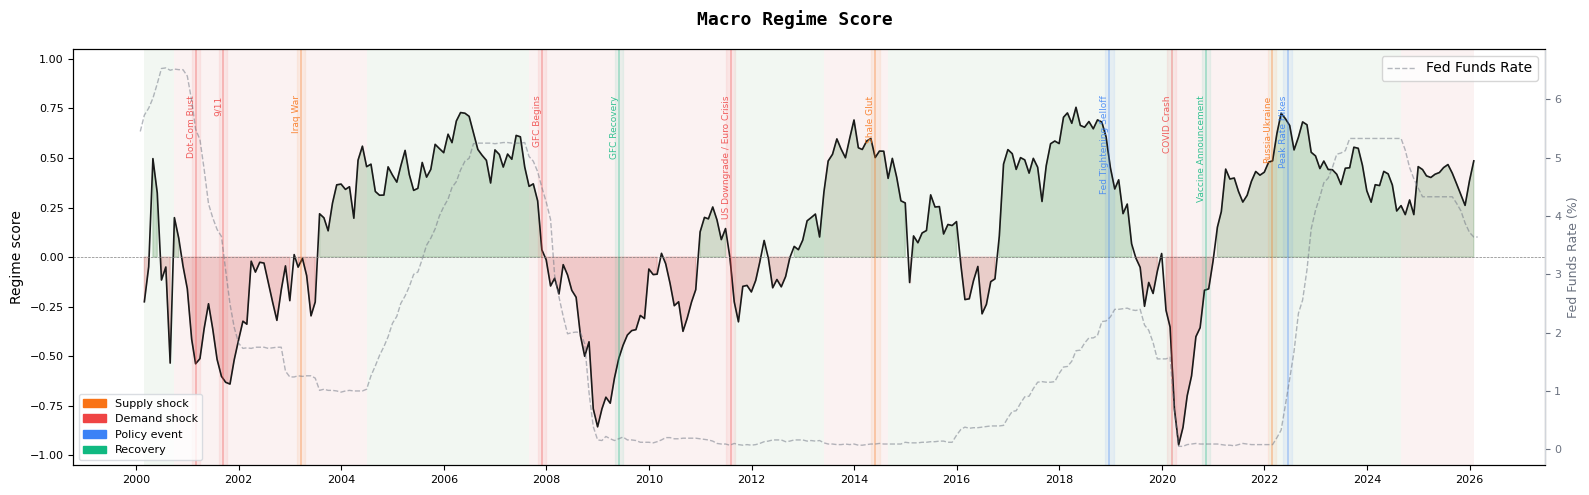

In [17]:
# --- Macro events ---
events = {
    '2001-03-01': ('Dot-Com Bust', 'demand'),
    '2001-09-11': ('9/11', 'demand'),
    '2003-03-20': ('Iraq War', 'supply'),
    '2007-12-01': ('GFC Begins', 'demand'),
    '2009-06-01': ('GFC Recovery', 'recovery'),
    '2011-08-05': ('US Downgrade / Euro Crisis', 'demand'),
    '2014-06-01': ('Shale Glut', 'supply'),
    '2018-12-24': ('Fed Tightening Selloff', 'policy'),
    '2020-03-11': ('COVID Crash', 'demand'),
    '2020-11-09': ('Vaccine Announcement', 'recovery'),
    '2022-02-24': ('Russia-Ukraine', 'supply'),
    '2022-06-15': ('Peak Rate Hikes', 'policy'),
}

COLOR = {
    'supply':'#F97316',
    'demand':'#EF4444',
    'policy':'#3B82F6',
    'recovery':'#10B981',
}

fig, ax = plt.subplots(figsize=(16, 5))


# Background: HMM regime shading
for t in range(len(z_scores) - 1):
    color = '#2e7d32' if hidden_states[t] == expansion_state else '#c62828'
    ax.axvspan(z_scores.index[t], z_scores.index[t+1],
               alpha=0.06, color=color, linewidth=0)

# Foreground: composite line
ax.plot(z_scores.index, composite, color='#1a1a1a', linewidth=1.2)
ax.fill_between(z_scores.index, composite, 0,
                where=composite > 0, alpha=0.2, color='#2e7d32')
ax.fill_between(z_scores.index, composite, 0,
                where=composite <= 0, alpha=0.2, color='#c62828')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

ax2 = ax.twinx()
ax2.plot(fed_funds.index, fed_funds.values,
         color='#6B7280', lw=1.0, alpha=0.5, linestyle='--',
         label='Fed Funds Rate')
ax2.set_ylabel('Fed Funds Rate (%)', fontsize=9, color='#6B7280')
ax2.tick_params(colors='#6B7280', labelsize=8)
ax2.spines['right'].set_edgecolor('#D1D5DB')

# Event overlays
for date_str, (label, etype) in events.items():
    dt = pd.Timestamp(date_str)
    c = COLOR[etype]
    ax.axvline(dt, color=c, lw=1.2, alpha=0.35, zorder=2)
    ax.axvspan(dt - pd.Timedelta(days=30), dt + pd.Timedelta(days=30),
               color=c, alpha=0.07, zorder=1)
    ax.text(dt, ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else 0.95,
            label, color=c, fontsize=6.5,
            rotation=90, va='top', ha='right', alpha=0.85)

ax.set_ylim(-1.05, 1.05)
ax.set_ylabel('Regime score', fontsize=10)
ax.tick_params(labelsize=8)

# X-axis: show all years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Legend
legend_handles = [
    mpatches.Patch(color=COLOR['supply'], label='Supply shock'),
    mpatches.Patch(color=COLOR['demand'], label='Demand shock'),
    mpatches.Patch(color=COLOR['policy'], label='Policy event'),
    mpatches.Patch(color=COLOR['recovery'], label='Recovery'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=8,
          facecolor='white', edgecolor='#D1D5DB')

fig.suptitle('Macro Regime Score',
             fontsize=13, fontfamily='monospace', fontweight='bold')
plt.tight_layout()
plt.legend()
plt.show()